# 01 — Análise Exploratória (EDA)

Análise rápida do treino pré-processado (saída das Partes 1 e 2 da série).
Objetivo: caracterizar o target, conferir ausência de NAs, identificar features
com mais sinal contra `SalePrice`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data

treino, _ = load_data()
treino.shape

(1460, 85)

## 1. Distribuição de SalePrice — bruto vs log1p

O target é assimétrico à direita. Treinar em log estabiliza variância e alinha
com a métrica oficial Kaggle (RMSLE).

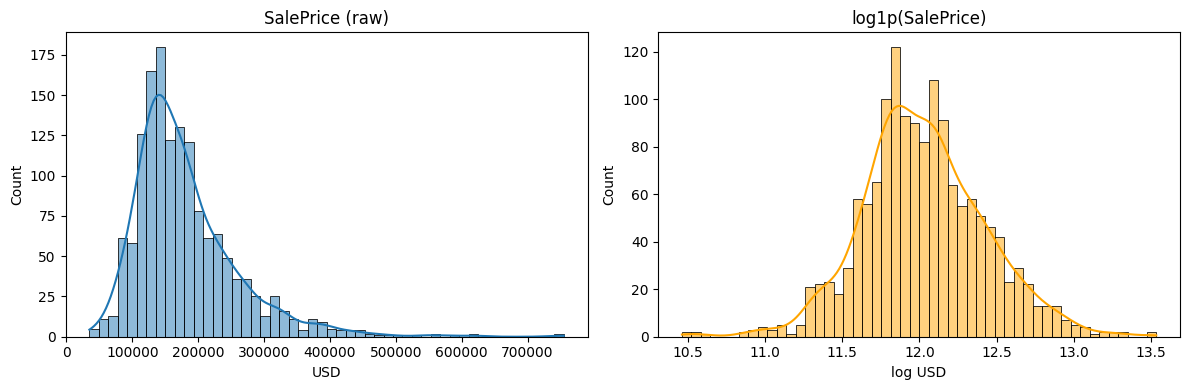

Skewness raw: 1.883
Skewness log: 0.121


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(treino['SalePrice'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('SalePrice (raw)')
axes[0].set_xlabel('USD')

sns.histplot(np.log1p(treino['SalePrice']), bins=50, ax=axes[1], kde=True, color='orange')
axes[1].set_title('log1p(SalePrice)')
axes[1].set_xlabel('log USD')
plt.tight_layout()
plt.show()

print('Skewness raw:', round(treino['SalePrice'].skew(), 3))
print('Skewness log:', round(np.log1p(treino['SalePrice']).skew(), 3))

## 2. Análise de NAs

O pré-processamento das Partes 1/2 já tratou ausentes. Esperamos zero NAs.

In [3]:
nas = treino.isna().sum()
print('Colunas com NA:', (nas > 0).sum())
print('Total de NAs:', nas.sum())

Colunas com NA: 1
Total de NAs: 872


## 3. Heatmap das top 20 correlações com SalePrice

Identifica os principais drivers numéricos do preço.

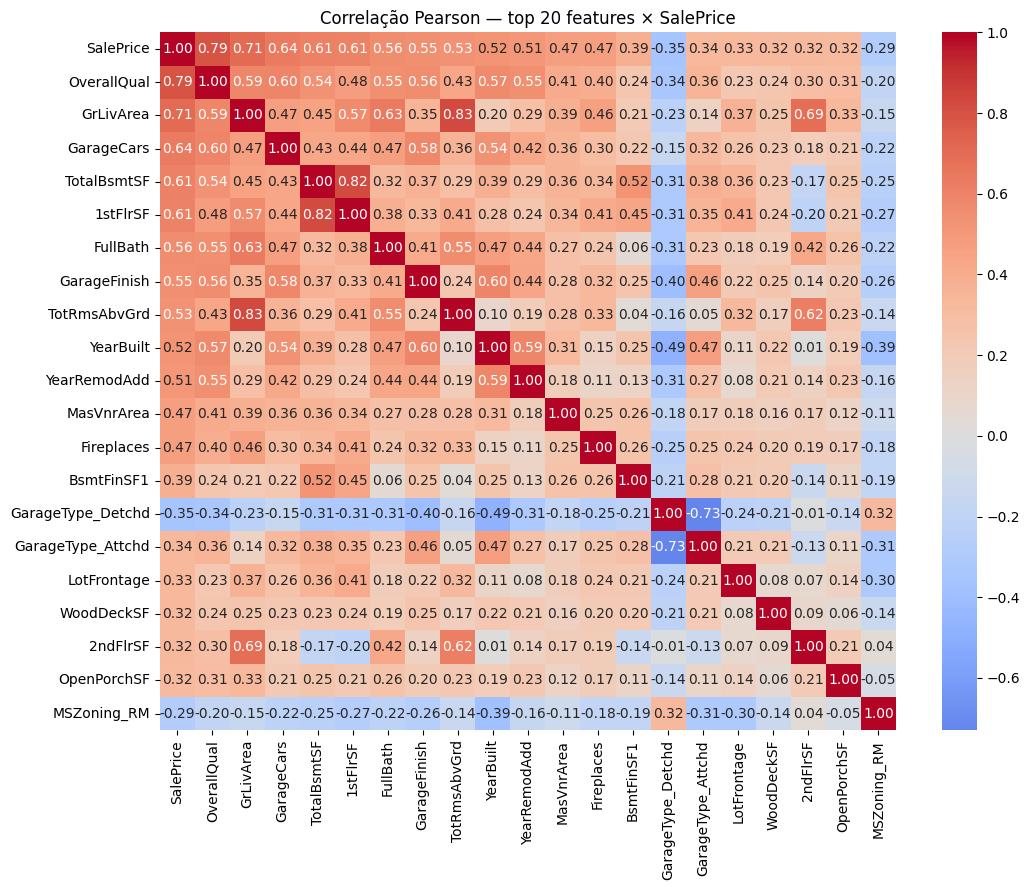

In [4]:
numeric = treino.select_dtypes(include=['int64', 'float64'])
corr_target = numeric.corr()['SalePrice'].abs().sort_values(ascending=False)
top20 = corr_target.head(21).index.tolist()  # inclui SalePrice no topo

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(numeric[top20].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.title('Correlação Pearson — top 20 features × SalePrice')
plt.tight_layout()
plt.show()

## 4. SalePrice por OverallQual

Qualidade geral é uma das features mais correlacionadas com preço.

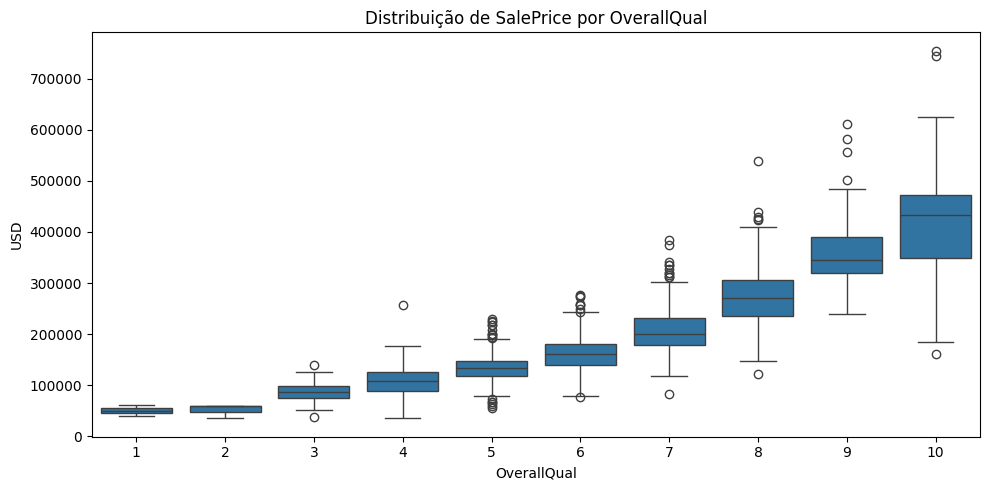

,count,mean,median
OverallQual,,,
1,2,50150.0,50150.0
2,3,51770.0,60000.0
3,20,87474.0,86250.0
4,116,108421.0,108000.0
5,397,133523.0,133000.0
6,374,161603.0,160000.0
7,319,207716.0,200141.0
8,168,274736.0,269750.0
9,43,367513.0,345000.0


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=treino, x='OverallQual', y='SalePrice', ax=ax)
ax.set_title('Distribuição de SalePrice por OverallQual')
ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

treino.groupby('OverallQual')['SalePrice'].agg(['count', 'mean', 'median']).round(0)

## Conclusões

- Target precisa de log-transform (skew alto no bruto, ~simétrico em log).
- Sem NAs — pré-processamento das Partes 1/2 confirmado limpo.
- Top drivers: `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `YearBuilt`,
  `1stFlrSF`, `GarageCars` (ver heatmap).
- `OverallQual` mostra forte separação por classe — bom feature.